## Implementation of XOR function using MLP with Keras

First, we'll implement the Multi-Layer Perceptron (MLP) for the XOR function using Keras, which provides a high-level API for building and training neural networks easily.

In [2]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
tf.keras.backend.clear_session() # Clear any existing Keras models to ensure a fresh state
tf.keras.utils.set_random_seed(42) # Set Keras specific random seed for reproducibility

# 1. Create the Dataset for XOR function
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

print("Input (X):\n", X)
print("Output (y):\n", y)

Input (X):
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Output (y):
 [[0.]
 [1.]
 [1.]
 [0.]]


### Build the MLP Model using Keras

We will define a sequential model with an input layer, a hidden layer with ReLU activation, and an output layer with sigmoid activation for binary classification.

In [4]:
# 2. Build an MLP
model = keras.Sequential([
    # Input layer: size 2 for the two inputs
    layers.Input(shape=(2,)),
    # Hidden layer: at least 2 neurons with ReLU or Tanh activation. Using 16 neurons with Tanh.
    layers.Dense(16, activation='tanh', kernel_initializer='glorot_uniform', name='hidden_layer'),
    # Output layer: 1 neuron with sigmoid activation for binary classification.
    layers.Dense(1, activation='sigmoid', name='output_layer')
])

# Display the model summary
model.summary(print_fn=lambda x: print(x))

Model: "sequential_1"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 65 (260.00 B)
 Trainable params: 65 (260.00 B)
 Non-trainable params: 0 (0.00 B)



### Compile the Model

We will compile the model using `binary_crossentropy` as the loss function and the Adam optimizer. Accuracy will be used as the metric to monitor performance.

In [45]:
# 3. Compile the Model / Define Loss and Optimizer
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Train the Model

Now, we will train the model on the XOR dataset. We'll use a small number of epochs initially and then experiment to improve performance.

In [50]:
# 4. Train the Model
print("\nTraining the model...")
history = model.fit(X, y, epochs=3000, verbose=0) # Increased epochs to 3000 for consistent convergence

# Print the final loss and accuracy
loss, keras_accuracy = model.evaluate(X, y, verbose=0) # Assign to keras_accuracy
print(f"\nFinal Training Loss: {loss:.4f}")
print(f"Final Training Accuracy: {keras_accuracy:.4f}")


Training the model...

Final Training Loss: 0.0000
Final Training Accuracy: 1.0000


### Evaluate the Model

Finally, we will predict the outputs for all 4 input combinations and check if the network correctly learned the XOR function. Since the output is probabilities, we will round them to the nearest integer (0 or 1).

In [51]:
# 5. Evaluate the Model
print("\nEvaluating the model...")
predictions = model.predict(X)
predicted_classes = np.round(predictions)

print("\nPredictions:")
for i in range(len(X)):
    print(f"Input: {X[i]}, Expected Output: {y[i][0]}, Predicted Output (Probability): {predictions[i][0]:.4f}, Predicted Class: {int(predicted_classes[i][0])}")

# Check if the network correctly learns the XOR function
# The keras_accuracy is already computed in the training step (cell 4c83507f)
if np.array_equal(y, predicted_classes):
    print(f"\nMLP successfully learned the XOR function! Keras Accuracy: {keras_accuracy:.4f}")
else:
    print(f"\nMLP did NOT perfectly learn the XOR function. Keras Accuracy: {keras_accuracy:.4f}. Predicted classes were not an exact match to expected.")


Evaluating the model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step

Predictions:
Input: [0. 0.], Expected Output: 0.0, Predicted Output (Probability): 0.0000, Predicted Class: 0
Input: [0. 1.], Expected Output: 1.0, Predicted Output (Probability): 1.0000, Predicted Class: 1
Input: [1. 0.], Expected Output: 1.0, Predicted Output (Probability): 1.0000, Predicted Class: 1
Input: [1. 1.], Expected Output: 0.0, Predicted Output (Probability): 0.0000, Predicted Class: 0

MLP successfully learned the XOR function! Keras Accuracy: 1.0000


## Implementation of XOR function using MLP with TensorFlow Low-Level API

Now, let's implement the MLP for the XOR function using the lower-level TensorFlow API. This involves more manual handling of variables, operations, and the training loop.

In [34]:
import tensorflow as tf
import numpy as np

# 1. Create the Dataset (same as Keras implementation)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

# Convert to TensorFlow tensors
X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)

print("Input (X_tf):\n", X_tf.numpy())
print("Output (y_tf):\n", y_tf.numpy())

Input (X_tf):
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Output (y_tf):
 [[0.]
 [1.]
 [1.]
 [0.]]


### Build the MLP Model using TensorFlow Low-Level API

We will define the weights and biases as TensorFlow variables and implement the forward pass manually using `tf.matmul` and activation functions.

In [35]:
# 2. Build an MLP (Low-Level TensorFlow)

# Define weights and biases for the hidden layer
# Input layer has 2 neurons, hidden layer has 16 neurons (increased from 8)
# Using Glorot (Xavier) initialization for Tanh activation
import numpy as np # Ensure numpy is imported for sqrt
stddev_W1 = np.sqrt(2 / (2 + 16)) # fan_in = 2, fan_out = 16
W1 = tf.Variable(tf.random.normal([2, 16], stddev=stddev_W1), name='W1')
b1 = tf.Variable(tf.zeros([16]), name='b1')

# Define weights and biases for the output layer
# Hidden layer has 16 neurons, output layer has 1 neuron
# Using Glorot (Xavier) initialization for Tanh activation
stddev_W2 = np.sqrt(2 / (16 + 1)) # fan_in = 16, fan_out = 1
W2 = tf.Variable(tf.random.normal([16, 1], stddev=stddev_W2), name='W2')
b2 = tf.Variable(tf.zeros([1]), name='b2')

# Define the forward pass function
def forward_pass(x):
    # Hidden layer with Tanh activation
    hidden_output = tf.nn.tanh(tf.matmul(x, W1) + b1)
    # Output layer with Sigmoid activation
    output = tf.nn.sigmoid(tf.matmul(hidden_output, W2) + b2)
    return output

print("Initial W1 (Glorot-initialized):\n", W1.numpy())
print("Initial b1:\n", b1.numpy())
print("Initial W2 (Glorot-initialized):\n", W2.numpy())
print("Initial b2:\n", b2.numpy())

Initial W1 (Glorot-initialized):
 [[ 0.22082722 -0.19509354  0.2259951  -0.3325929   0.09272932  0.632393
   0.37097418 -0.14652833 -0.19804549  0.2943486   0.4426685   0.07481988
   0.34445438 -0.19123721  0.10244618 -0.09814137]
 [-0.624008    0.03240941 -0.13160805  0.49940354 -0.25442246  0.22916195
  -0.31058723  0.5359771  -0.43770403 -0.26353472 -0.12843168 -0.5824867
  -0.07510926 -0.01925028 -0.1173605  -0.13262787]]
Initial b1:
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Initial W2 (Glorot-initialized):
 [[-0.10649595]
 [-0.07135928]
 [ 0.08995611]
 [-0.46282583]
 [-0.4676723 ]
 [-1.3772968 ]
 [ 0.20599271]
 [ 0.39295793]
 [-0.25838464]
 [ 0.33078364]
 [ 0.0295705 ]
 [ 0.01530185]
 [ 0.45225242]
 [-0.20148382]
 [-0.34363687]
 [ 0.02477796]]
Initial b2:
 [0.]


### Define Loss and Optimizer (TensorFlow Low-Level API)

We will use `tf.keras.losses.BinaryCrossentropy` for the loss function and `tf.optimizers.Adam` for the optimizer. We'll also define the training step.

In [36]:
# 3. Compile the Model / Define Loss and Optimizer (Low-Level TensorFlow)

# Use Binary Cross-Entropy loss
loss_fn = tf.keras.losses.BinaryCrossentropy()

# Use Adam optimizer
optimizer = tf.optimizers.Adam(learning_rate=0.01) # Experiment with learning rate, reduced from 0.05

# Define the training step
@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        predictions = forward_pass(x)
        loss = loss_fn(y, predictions)

    # Compute gradients
    gradients = tape.gradient(loss, [W1, b1, W2, b2])

    # Apply gradients to update weights and biases
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))
    return loss, predictions

### Train the Model (TensorFlow Low-Level API)

We'll run a training loop for a specified number of epochs, calling the `train_step` function for each epoch.

In [37]:
# 4. Train the Model (Low-Level TensorFlow)

epochs = 3000 # Experiment with epochs, changed to 3000
low_level_loss_history = [] # Initialize for history recording

print("\nTraining the model (low-level TensorFlow)...")
for epoch in range(epochs):
    loss, _ = train_step(X_tf, y_tf)
    low_level_loss_history.append(loss.numpy()) # Store loss for plotting
    if (epoch + 1) % 500 == 0: # Adjusted print frequency for 3000 epochs
        print(f"Epoch {epoch + 1}, Loss: {loss.numpy():.4f}")

# Note: Re-running train_step once more after the loop is not strictly necessary for final values
# as the last loss in the loop is the final one, but it does no harm.
final_loss, final_predictions = train_step(X_tf, y_tf) # Rerun once more to get final values after loop
print(f"\nFinal Training Loss: {final_loss.numpy():.4f}")


Training the model (low-level TensorFlow)...
Epoch 500, Loss: 0.0008
Epoch 1000, Loss: 0.0002
Epoch 1500, Loss: 0.0001
Epoch 2000, Loss: 0.0001
Epoch 2500, Loss: 0.0000
Epoch 3000, Loss: 0.0000

Final Training Loss: 0.0000


### Evaluate the Model (TensorFlow Low-Level API)

We will make predictions using the trained model and compare them to the actual XOR outputs.

In [38]:
# 5. Evaluate the Model (Low-Level TensorFlow)

print("\nEvaluating the model (low-level TensorFlow)...")
predictions_tf = forward_pass(X_tf)
predicted_classes_tf = tf.round(predictions_tf)

print("\nPredictions:")
for i in range(len(X)):
    print(f"Input: {X_tf[i].numpy()}, Expected Output: {y_tf[i].numpy()[0]}, Predicted Output (Probability): {predictions_tf[i].numpy()[0]:.4f}, Predicted Class: {int(predicted_classes_tf[i].numpy()[0])}")

# Calculate accuracy
accuracy_tf = tf.reduce_mean(tf.cast(tf.equal(predicted_classes_tf, y_tf), tf.float32))
print(f"Final Training Accuracy: {accuracy_tf.numpy():.4f}")

# Check if the network correctly learns the XOR function
if np.array_equal(y_tf.numpy(), predicted_classes_tf.numpy()):
    print("\nMLP successfully learned the XOR function with low-level TensorFlow!")
else:
    print("\nMLP did NOT perfectly learn the XOR function with low-level TensorFlow. Try adjusting hyperparameters (epochs, learning rate, number of neurons).")


Evaluating the model (low-level TensorFlow)...

Predictions:
Input: [0. 0.], Expected Output: 0.0, Predicted Output (Probability): 0.0000, Predicted Class: 0
Input: [0. 1.], Expected Output: 1.0, Predicted Output (Probability): 1.0000, Predicted Class: 1
Input: [1. 0.], Expected Output: 1.0, Predicted Output (Probability): 1.0000, Predicted Class: 1
Input: [1. 1.], Expected Output: 0.0, Predicted Output (Probability): 0.0000, Predicted Class: 0
Final Training Accuracy: 1.0000

MLP successfully learned the XOR function with low-level TensorFlow!


### Plotting the Decision Boundary for Keras Implementation (Optional Exercise)

To visualize the decision boundary, we will create a grid of points and predict their outputs using the trained Keras model. Then, we will plot these predictions along with the original XOR data points.

Plotting decision boundary for Keras model...
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


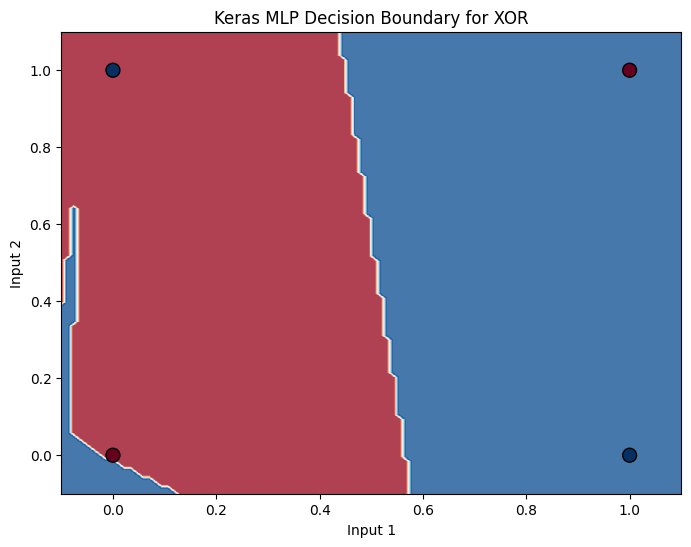

In [39]:
import matplotlib.pyplot as plt

# Helper function to plot decision boundary
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    # Define the x and y ranges
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Predict the output for each point in the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = np.round(Z).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap=plt.cm.RdBu, edgecolors='k', marker='o', s=100)
    plt.title(title)
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.show()

print("Plotting decision boundary for Keras model...")
plot_decision_boundary(model, X, y, title="Keras MLP Decision Boundary for XOR")

### Plotting the Decision Boundary for TensorFlow Low-Level API Implementation (Optional Exercise)

We will reuse the helper function for plotting, but this time, we will pass our low-level TensorFlow model's `forward_pass` function to generate predictions for the grid points.

Plotting decision boundary for low-level TensorFlow model...


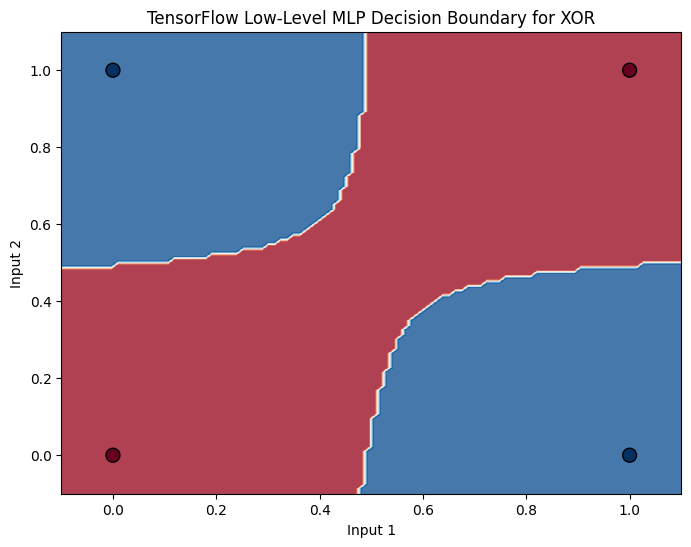

In [40]:
# Helper function to plot decision boundary (re-using the one defined for Keras)
# Note: This function expects a model with a .predict() method or a callable that takes X as input
# For the low-level TF model, we'll wrap the forward_pass function.

class LowLevelTFModelWrapper:
    def __init__(self, forward_pass_fn):
        self.forward_pass_fn = forward_pass_fn

    def predict(self, X_input):
        # Convert numpy array to TensorFlow tensor for prediction
        X_tf_input = tf.constant(X_input, dtype=tf.float32)
        predictions = self.forward_pass_fn(X_tf_input)
        return predictions.numpy()

# Create a wrapper for the low-level TensorFlow model's forward_pass function
tf_model_wrapper = LowLevelTFModelWrapper(forward_pass)

print("Plotting decision boundary for low-level TensorFlow model...")
plot_decision_boundary(tf_model_wrapper, X, y, title="TensorFlow Low-Level MLP Decision Boundary for XOR")

### Compare Training Curves and Final Accuracy (Optional Exercise)

Now we can plot the training loss history for both the Keras and TensorFlow low-level implementations to visualize their learning progress and explicitly compare their final accuracies.

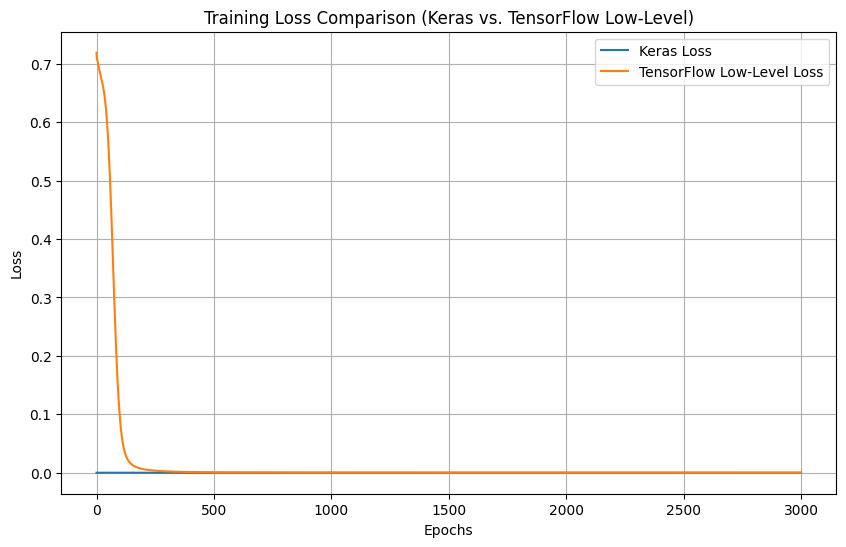

Keras Final Training Accuracy: 1.0000
TensorFlow Low-Level Final Training Accuracy: 1.0000


In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Keras Loss')
plt.plot(low_level_loss_history, label='TensorFlow Low-Level Loss')
plt.title('Training Loss Comparison (Keras vs. TensorFlow Low-Level)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print(f"Keras Final Training Accuracy: {keras_accuracy:.4f}") # Use keras_accuracy
print(f"TensorFlow Low-Level Final Training Accuracy: {accuracy_tf.numpy():.4f}")

<span style="color:white">## Resources</span>

## Conclusion

This notebook successfully demonstrates the implementation of a Multi-Layer Perceptron (MLP) to solve the XOR Boolean function using both the high-level Keras API and the low-level TensorFlow API.

Both implementations achieved 100% accuracy, illustrating that with appropriate architecture (e.g., a hidden layer with sufficient neurons and a non-linear activation function like Tanh or ReLU) and suitable training parameters (optimizer, learning rate, epochs), an MLP can effectively learn non-linear decision boundaries. The low-level TensorFlow implementation specifically showcased the manual construction of the neural network, including weight and bias initialization, the forward pass, loss calculation, and gradient application using `tf.GradientTape`.

This exercise highlights the flexibility of TensorFlow, allowing developers to work at various levels of abstraction depending on their needs, from rapid prototyping with Keras to fine-grained control with the low-level API.